In [1]:
from nltk import word_tokenize
from nltk.corpus import stopwords
from pymongo import MongoClient
import pandas as pd

from Youtube.youtube_api_scripts.config import MONGO_DB, MONGO_URI, MONGO_COLL
import matplotlib.pyplot as plt

In [2]:
with MongoClient(MONGO_URI) as client:
    db = client[MONGO_DB]
    collection = db[MONGO_COLL]

    limit_results = 0
    # Fetch the latest 5000 documents sorted by updated_at in descending order
    with collection.find().sort('updated_at', -1).limit(limit_results) as cursor:
        data = pd.DataFrame(list(cursor))

data

,_id,comment_id,author,author_channel_id,channel_id,channel_name,like_count,published_at,text,updated_at,video_id,video_title
0,683deba4d286f35c0b797ef9,Ugw4YK-ao1Rh7qB8BX94AaABAg,@J_KhayGaming,{'value': 'UCGdaHJbAIRwJzHH1aArjtnA'},UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T17:58:33Z,i stg if Kel'thuzad returns somehow...,2025-06-02T17:58:33Z,9sqxmxuFKHg,WoW's Final Expansion Has A HUGE Secret.…
1,683deba4d286f35c0b797efa,Ugy7I_HPZCYSRlNXcQp4AaABAg,@NicoleMay316,{'value': 'UCQit86fze22NGAHar9Bl0fw'},UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T17:58:32Z,"More than anything, I want a non-time limited ...",2025-06-02T17:58:32Z,FslljyMcYPI,Blizzard Is Saving WoW's Story — This Is FANTA...
2,683deba4d286f35c0b797efb,UgyUEtw2LTwHU7uKIMJ4AaABAg,@Hybridsixtynine,{'value': 'UCCP2C6JSNtsEqwIU9LMSRUA'},UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T17:32:23Z,The pipe organ playing in the theme music stil...,2025-06-02T17:32:35Z,9sqxmxuFKHg,WoW's Final Expansion Has A HUGE Secret.…
3,683deba4d286f35c0b797efc,UgztxOK3AVZDMsuqLj94AaABAg,@MrToastmaster2009,{'value': 'UCR1QaOyqwM6VGMg_3pfbJUQ'},UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T17:09:14Z,"Final expansion, you got me all depressed. I c...",2025-06-02T17:09:14Z,9sqxmxuFKHg,WoW's Final Expansion Has A HUGE Secret.…
4,683deba4d286f35c0b797efd,UgzGorsIOz8MzDSk5Tx4AaABAg,@Rhyden_Thorne,{'value': 'UCUgYXsfBTh_PF6fg5yljQaA'},UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T16:40:48Z,This is genuinely fantastic. \n\nI really real...,2025-06-02T16:40:48Z,FslljyMcYPI,Blizzard Is Saving WoW's Story — This Is FANTA...
...,...,...,...,...,...,...,...,...,...,...,...,...
3056144,6788ed51eaf88b06c403ede3,UgxM9w7zIATkRtamuBl4AaABAg,@JontePlugg,{'value': 'UCKSRJ5ZgnH5kAPryZN0LWmw'},UCvV80raFP2R7X0yxH9iJjog,GingiTV,0,2013-09-16T15:22:37Z,did you config elvui yourself? or is that a co...,1970-01-01T00:00:00Z,K4Hn34aWues,Scarlet Monastery 4:30
3056145,6788ed51eaf88b06c403ede4,Ugx_GeswWh8hfeof7pV4AaABAg,@GingiTV,{'value': 'UCvV80raFP2R7X0yxH9iJjog'},UCvV80raFP2R7X0yxH9iJjog,GingiTV,0,2013-09-15T17:39:04Z,"Salyin Battle Banner, drops from a dude in val...",1970-01-01T00:00:00Z,K4Hn34aWues,Scarlet Monastery 4:30
3056146,6788ed51eaf88b06c403ede5,UgxA_glbUquVlJNFTsp4AaABAg,@Luiskaah,{'value': 'UCqL1SNyTen4xV6c5pSdVEiA'},UCvV80raFP2R7X0yxH9iJjog,GingiTV,0,2013-09-14T19:45:10Z,Hello! Really nice run. What do you use to res...,1970-01-01T00:00:00Z,K4Hn34aWues,Scarlet Monastery 4:30
3056147,6788ed51eaf88b06c403ede6,Ugw4kFnZtwOOoXsJxdR4AaABAg,@ZortherPwnz,{'value': 'UCUxPIFICN0ugugp9vECumaA'},UCvV80raFP2R7X0yxH9iJjog,GingiTV,0,2013-09-14T13:29:36Z,So me the way master !\n,1970-01-01T00:00:00Z,4gu7VPFrXK0,Scarlet Halls 3:50


In [3]:
df = data.copy()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3056149 entries, 0 to 3056148
Data columns (total 12 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   _id                object
 1   comment_id         object
 2   author             object
 3   author_channel_id  object
 4   channel_id         object
 5   channel_name       object
 6   like_count         int64 
 7   published_at       object
 8   text               object
 9   updated_at         object
 10  video_id           object
 11  video_title        object
dtypes: int64(1), object(11)
memory usage: 279.8+ MB


In [5]:
df = df[
    ['comment_id', 'channel_id', 'channel_name', 'like_count', 'published_at', 'updated_at', 'video_id', 'video_title',
     'text']]

In [6]:
df

,comment_id,channel_id,channel_name,like_count,published_at,updated_at,video_id,video_title,text
0,Ugw4YK-ao1Rh7qB8BX94AaABAg,UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T17:58:33Z,2025-06-02T17:58:33Z,9sqxmxuFKHg,WoW's Final Expansion Has A HUGE Secret.…,i stg if Kel'thuzad returns somehow...
1,Ugy7I_HPZCYSRlNXcQp4AaABAg,UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T17:58:32Z,2025-06-02T17:58:32Z,FslljyMcYPI,Blizzard Is Saving WoW's Story — This Is FANTA...,"More than anything, I want a non-time limited ..."
2,UgyUEtw2LTwHU7uKIMJ4AaABAg,UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T17:32:23Z,2025-06-02T17:32:35Z,9sqxmxuFKHg,WoW's Final Expansion Has A HUGE Secret.…,The pipe organ playing in the theme music stil...
3,UgztxOK3AVZDMsuqLj94AaABAg,UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T17:09:14Z,2025-06-02T17:09:14Z,9sqxmxuFKHg,WoW's Final Expansion Has A HUGE Secret.…,"Final expansion, you got me all depressed. I c..."
4,UgzGorsIOz8MzDSk5Tx4AaABAg,UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T16:40:48Z,2025-06-02T16:40:48Z,FslljyMcYPI,Blizzard Is Saving WoW's Story — This Is FANTA...,This is genuinely fantastic. \n\nI really real...
...,...,...,...,...,...,...,...,...,...
3056144,UgxM9w7zIATkRtamuBl4AaABAg,UCvV80raFP2R7X0yxH9iJjog,GingiTV,0,2013-09-16T15:22:37Z,1970-01-01T00:00:00Z,K4Hn34aWues,Scarlet Monastery 4:30,did you config elvui yourself? or is that a co...
3056145,Ugx_GeswWh8hfeof7pV4AaABAg,UCvV80raFP2R7X0yxH9iJjog,GingiTV,0,2013-09-15T17:39:04Z,1970-01-01T00:00:00Z,K4Hn34aWues,Scarlet Monastery 4:30,"Salyin Battle Banner, drops from a dude in val..."
3056146,UgxA_glbUquVlJNFTsp4AaABAg,UCvV80raFP2R7X0yxH9iJjog,GingiTV,0,2013-09-14T19:45:10Z,1970-01-01T00:00:00Z,K4Hn34aWues,Scarlet Monastery 4:30,Hello! Really nice run. What do you use to res...
3056147,Ugw4kFnZtwOOoXsJxdR4AaABAg,UCvV80raFP2R7X0yxH9iJjog,GingiTV,0,2013-09-14T13:29:36Z,1970-01-01T00:00:00Z,4gu7VPFrXK0,Scarlet Halls 3:50,So me the way master !\n


In [7]:
print(df['video_title'].isna().count())

3056149


In [8]:
df[df['video_title'].isna()]

,comment_id,channel_id,channel_name,like_count,published_at,updated_at,video_id,video_title,text
359829,UgzcSAsE7dgU7jnJjbJ4AaABAg,UCj-Tw9GZaRL8geA6HvOhVug,MoreMrGM,0,2024-05-13T01:56:54Z,2024-05-13T01:56:54Z,fPokom48AsM,None,MrGM i love you😊
362725,Ugzc2VU0cfH7hUagr1N4AaABAg,UCj-Tw9GZaRL8geA6HvOhVug,MoreMrGM,1,2024-05-09T07:15:47Z,2024-05-09T07:15:47Z,ktEFnzgnPYY,None,What mount is that that he’s using? I can’t se...
369284,UgymF1vOPgG3hQ1npGt4AaABAg,UCj-Tw9GZaRL8geA6HvOhVug,MoreMrGM,0,2024-05-02T14:17:53Z,2024-05-02T14:17:53Z,3CLnwj-KNMU,None,I have the wow installed on my deck it will lo...
374132,UgwUhUbF6HTXuGr5hAZ4AaABAg,UCj-Tw9GZaRL8geA6HvOhVug,MoreMrGM,0,2024-04-27T04:28:05Z,2024-04-27T14:37:05Z,538hGYrKeWM,None,"After 8 years of M+, I think this is not going..."
377665,UgyGqkprNd6O4-z4GZV4AaABAg,UCj-Tw9GZaRL8geA6HvOhVug,MoreMrGM,0,2024-04-23T14:00:19Z,2024-04-23T14:00:19Z,fJXMnRtRanQ,None,That guy who speaks of a word of power is Locu...
...,...,...,...,...,...,...,...,...,...
1081822,Ugy6innBz3xmgGyMOqd4AaABAg,UCj-Tw9GZaRL8geA6HvOhVug,MoreMrGM,31,2022-04-07T10:08:54Z,2022-04-07T10:08:54Z,nEjZjIcHHII,None,Great information and knowledge as always. It'...
1085764,UgwkkI6wYffCDmmpoPJ4AaABAg,UCj-Tw9GZaRL8geA6HvOhVug,MoreMrGM,0,2022-04-03T13:38:13Z,2022-04-03T13:38:13Z,nEjZjIcHHII,None,How is BoD gonna work😂
1087982,UgxY6aJffvsGrptuX1R4AaABAg,UCj-Tw9GZaRL8geA6HvOhVug,MoreMrGM,0,2022-04-01T02:11:58Z,2022-04-01T02:11:58Z,nEjZjIcHHII,None,"This is illegal , it should be a crime."
2612246,UgynwmG9dGTW0tZXhF94AaABAg,UCyf0SCaSGhKpvI_azfvidUw,MarcelianOnline,1,2018-07-01T19:03:07Z,2018-07-01T19:03:07Z,j98hK_L7yJM,None,Lord Savix we are pleased to have you


In [9]:
# Fill NaNs in the column "video_title" with the value "Shorts"
df['video_title'] = df['video_title'].fillna('Shorts')

In [10]:
df

,comment_id,channel_id,channel_name,like_count,published_at,updated_at,video_id,video_title,text
0,Ugw4YK-ao1Rh7qB8BX94AaABAg,UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T17:58:33Z,2025-06-02T17:58:33Z,9sqxmxuFKHg,WoW's Final Expansion Has A HUGE Secret.…,i stg if Kel'thuzad returns somehow...
1,Ugy7I_HPZCYSRlNXcQp4AaABAg,UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T17:58:32Z,2025-06-02T17:58:32Z,FslljyMcYPI,Blizzard Is Saving WoW's Story — This Is FANTA...,"More than anything, I want a non-time limited ..."
2,UgyUEtw2LTwHU7uKIMJ4AaABAg,UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T17:32:23Z,2025-06-02T17:32:35Z,9sqxmxuFKHg,WoW's Final Expansion Has A HUGE Secret.…,The pipe organ playing in the theme music stil...
3,UgztxOK3AVZDMsuqLj94AaABAg,UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T17:09:14Z,2025-06-02T17:09:14Z,9sqxmxuFKHg,WoW's Final Expansion Has A HUGE Secret.…,"Final expansion, you got me all depressed. I c..."
4,UgzGorsIOz8MzDSk5Tx4AaABAg,UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T16:40:48Z,2025-06-02T16:40:48Z,FslljyMcYPI,Blizzard Is Saving WoW's Story — This Is FANTA...,This is genuinely fantastic. \n\nI really real...
...,...,...,...,...,...,...,...,...,...
3056144,UgxM9w7zIATkRtamuBl4AaABAg,UCvV80raFP2R7X0yxH9iJjog,GingiTV,0,2013-09-16T15:22:37Z,1970-01-01T00:00:00Z,K4Hn34aWues,Scarlet Monastery 4:30,did you config elvui yourself? or is that a co...
3056145,Ugx_GeswWh8hfeof7pV4AaABAg,UCvV80raFP2R7X0yxH9iJjog,GingiTV,0,2013-09-15T17:39:04Z,1970-01-01T00:00:00Z,K4Hn34aWues,Scarlet Monastery 4:30,"Salyin Battle Banner, drops from a dude in val..."
3056146,UgxA_glbUquVlJNFTsp4AaABAg,UCvV80raFP2R7X0yxH9iJjog,GingiTV,0,2013-09-14T19:45:10Z,1970-01-01T00:00:00Z,K4Hn34aWues,Scarlet Monastery 4:30,Hello! Really nice run. What do you use to res...
3056147,Ugw4kFnZtwOOoXsJxdR4AaABAg,UCvV80raFP2R7X0yxH9iJjog,GingiTV,0,2013-09-14T13:29:36Z,1970-01-01T00:00:00Z,4gu7VPFrXK0,Scarlet Halls 3:50,So me the way master !\n


In [11]:
df['channel_name'].unique()

array(['Bellular Warcraft', 'Dvalin Gaming', 'MrGM', 'MarcelianOnline',
       'Tettles', 'The PoddyC', 'Nobbel87', 'Hopeful', 'SoulSoBreezy',
       'World of Warcraft', 'MoreMrGM', 'Scottejaye', 'GingiTV',
       'AutomaticJak', 'Dalaran Gaming', 'Xaryu', 'WillE', 'Venruki',
       'Platinum WoW', 'Taliesin & Evitel', 'Dratnos', 'SignsOfKelani',
       'Accolonn', 'yumytv', 'Preach Gaming', 'Asmongold TV  ', 'Dorki',
       'Maximum', 'Hazelnuttygames', 'Mad Skillz', 'Towelliee', 'Naguura'],
      dtype=object)

In [12]:
df['video_title'].unique()

array(["WoW's Final Expansion Has A HUGE Secret.…",
       "Blizzard Is Saving WoW's Story — This Is FANTASTIC",
       'The Limits Are WILD: WoW’s Housing Crushes The Competition', ...,
       "Let's Play Interactive Skyrim E3 - Riverwood",
       'Gate of the Setting Sun 5:38', 'Shado-Pan Monastery 9:15'],
      dtype=object)

In [13]:
bfa_tww = df[df['published_at'] >= "2018-08-14"]

In [14]:
bfa_tww

,comment_id,channel_id,channel_name,like_count,published_at,updated_at,video_id,video_title,text
0,Ugw4YK-ao1Rh7qB8BX94AaABAg,UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T17:58:33Z,2025-06-02T17:58:33Z,9sqxmxuFKHg,WoW's Final Expansion Has A HUGE Secret.…,i stg if Kel'thuzad returns somehow...
1,Ugy7I_HPZCYSRlNXcQp4AaABAg,UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T17:58:32Z,2025-06-02T17:58:32Z,FslljyMcYPI,Blizzard Is Saving WoW's Story — This Is FANTA...,"More than anything, I want a non-time limited ..."
2,UgyUEtw2LTwHU7uKIMJ4AaABAg,UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T17:32:23Z,2025-06-02T17:32:35Z,9sqxmxuFKHg,WoW's Final Expansion Has A HUGE Secret.…,The pipe organ playing in the theme music stil...
3,UgztxOK3AVZDMsuqLj94AaABAg,UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T17:09:14Z,2025-06-02T17:09:14Z,9sqxmxuFKHg,WoW's Final Expansion Has A HUGE Secret.…,"Final expansion, you got me all depressed. I c..."
4,UgzGorsIOz8MzDSk5Tx4AaABAg,UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2025-06-02T16:40:48Z,2025-06-02T16:40:48Z,FslljyMcYPI,Blizzard Is Saving WoW's Story — This Is FANTA...,This is genuinely fantastic. \n\nI really real...
...,...,...,...,...,...,...,...,...,...
2577267,UgxsC4MKzy2yJ6BLl454AaABAg,UCwiaPYufmQOq5F1TI-FzQhw,Bellular Warcraft,0,2018-08-14T00:25:15Z,2018-08-14T00:25:15Z,C_b0VdjBRoU,HIT 120 FAST: Ultimate Battle for Azeroth Leve...,"Thanks Balulis, because your addon that shares..."
2577268,UgyUBz84JJDb7bz-19F4AaABAg,UCiHdR2hAyFEXWCbNQgbu_Dg,Taliesin & Evitel,0,2018-08-14T00:24:14Z,2018-08-14T00:24:14Z,C2Sr-sadSk4,High Elves And Battle For Azeroth: The Allied ...,I dont care how they have twisted the lore now...
2577269,UgyyhHm8BjPV09LIZsN4AaABAg,UCX34tk-noBVC4WVC9qQGyMw,Nobbel87,0,2018-08-14T00:24:04Z,2018-08-14T00:24:04Z,F3P6LJDB9QI,The Story of Sylvanas Windrunner: Edge of Nigh...,Arrows in a quiver
2577270,Ugz2BkpUqIjN8_OTAxp4AaABAg,UCX34tk-noBVC4WVC9qQGyMw,Nobbel87,0,2018-08-14T00:15:55Z,2018-08-14T00:15:55Z,MfYQzxPXNw0,The Story of Jaina Proudmoore - - Part 1 of 4 ...,Why are the peeps of Kul Tiras angry with Jain...


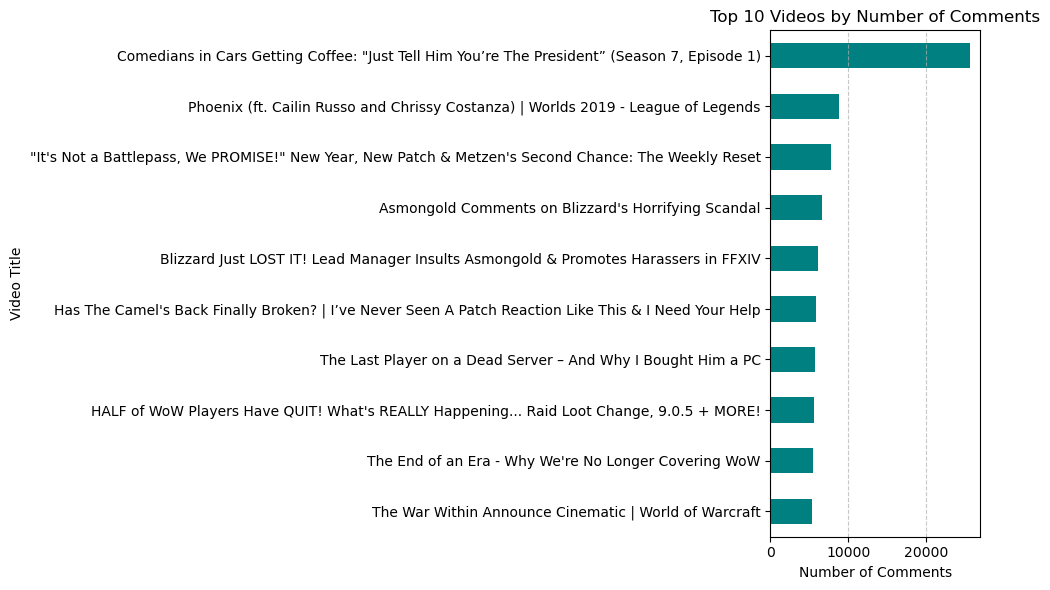

In [15]:
video_comment_counts = bfa_tww['video_title'].value_counts().head(10)
plt.figure(figsize=(10, 6))
video_comment_counts.sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Videos by Number of Comments')
plt.xlabel('Number of Comments')
plt.ylabel('Video Title')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [16]:
print("\nUnique video titles:\n")
# Filter out None values before sorting
unique_titles = [title for title in df.video_title.unique() if title is not None]
unique_titles.sort()
unique_titles


Unique video titles:



['"2600 PLAYERS HUH?" - (Combat Rogue PvP) Warlords of Draenor 6.2.3',
 '"A Really Good Rogue" (5v5 1v1 Duels) - Not Ret Paladin PvP WoW Legion 7.3.5',
 '"ARE YOU READY FOR THIS BURST?" - (Assassination Rogue PvP) Warlords of Draenor 6.2.3',
 '"Accolonn Do You THINK Dragonflight Will Be GOOD" ??',
 '"Accolonn Does the Forsaken Have a Future WITHOUT Sylvanas" ??',
 '"Accolonn Have You REPLACED WoW with WARHAMMER 40K" - World of Warcraft Dragonflight - LORE Q&A',
 '"Accolonn How Can The Light Create Undead" ??',
 '"Accolonn Was Sylvanas\'s Story CHANGED" ??',
 '"Accolonn What Happens to Bolvar" - World of Warcraft Dragonflight - LORE Q&A',
 '"Accolonn What\'s the Best Book You\'ve EVER Read" ??',
 '"Accolonn Who Will Be The NEXT BLACK DRAGON ASPECT" ??',
 '"Accolonn Who is An\'she" - World of Warcraft Dragonflight - LORE Q&A',
 '"Accolonn Why Cant We DYE our Armors in WoW" ??',
 '"Accolonn Will Illidan Return in Dragonflight" - World of Warcraft Dragonflight - LORE Q&A',
 '"Accolonn is W

In [17]:
import re

from bs4 import BeautifulSoup
import ftfy
import nltk
from nltk import word_tokenize


def clean_text(text: str) -> str:
    # Fix unicode issues
    text = ftfy.fix_text(text)
    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text(" ")
    # Lowercase
    text = text.lower()
    # Remove email addresses
    text = re.sub(r'\S+@\S+\.\S+', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove patch numbers
    text = re.sub(r'\b\d+(\.\d+){1,2}\b', '', text)
    # Remove non-alphanumeric characters except '+',"'",'-'
    text = re.sub(r'[^a-z0-9\s\+\'\-]', ' ', text)
    # Replace "'" with no space
    text = re.sub(r'\'', '', text)
    # Remove stopwords
    tokens = word_tokenize(text)
    text = " ".join([t for t in tokens if t not in stopwords.words('english')])
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Demonstration
sample = '<p>My key is +15 M+. Contact me: me@example.com!</p>\n'
print(clean_text(sample))


key +15 m+ contact


In [18]:
keywords_df = pd.read_csv('all_words_v2.csv')
keywords_df['clean_term'] = keywords_df['term'].apply(clean_text)
keywords_df

,term,clean_term
0,AB,ab
1,AK,ak
2,AP,ap
3,AQ,aq
4,AQ20,aq20
...,...,...
719,ilevel,ilevel
720,nerubian,nerubian
721,squish,squish
722,visage,visage


In [19]:
keywords = keywords_df['clean_term']

In [20]:
keywords.drop_duplicates(inplace=True)

In [21]:
keywords_list = keywords.tolist()

In [22]:
# keywords_list = list(set(keywords_clean['term'].astype(str)))
titles_clean = [clean_text(title) for title in unique_titles]

C:\Users\sarah\AppData\Local\Temp\ipykernel_97524\3003176316.py:13: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  text = BeautifulSoup(text, "html.parser").get_text(" ")


In [23]:
titles_clean

['2600 players huh - combat rogue pvp warlords draenor',
 'really good rogue 5v5 1v1 duels - ret paladin pvp wow legion',
 'ready burst - assassination rogue pvp warlords draenor',
 'accolonn think dragonflight good',
 'accolonn forsaken future without sylvanas',
 'accolonn replaced wow warhammer 40k - world warcraft dragonflight - lore qa',
 'accolonn light create undead',
 'accolonn sylvanass story changed',
 'accolonn happens bolvar - world warcraft dragonflight - lore qa',
 'accolonn whats best book youve ever read',
 'accolonn next black dragon aspect',
 'accolonn anshe - world warcraft dragonflight - lore qa',
 'accolonn cant dye armors wow',
 'accolonn illidan return dragonflight - world warcraft dragonflight - lore qa',
 'accolonn warcraft becoming peacecraft',
 'accolonn wow doomed fail - world warcraft dragonflight - lore qa',
 'accolonn world warcraft based warhammer - world warcraft dragonflight - lore qa',
 'account wide heartbreaker mount drop increase relates wows future

In [24]:
jargon_regex = r'\b(?:' + '|'.join(re.escape(keyword) for keyword in keywords_list) + r')\b'

matches = list()
no_matches = list()

for title in titles_clean:
    if re.search(jargon_regex, title):
        matches.append(title)
    else:
        no_matches.append(title)


In [25]:
len(matches), len(no_matches)

(33832, 5)

In [26]:
no_matches

['', '', '', '', '']

In [27]:
matches = list()
no_matches = list()

for title in unique_titles:
    if re.search('FFXIV', title):
        matches.append(title)
    else:
        no_matches.append(title)

In [28]:
matches

['10yr WoW Vet Tries FFXIV, First Impressions and Streaming Plans!',
 "9.1 Is WoW's LAST CHANCE (Again) And What They Should Learn From FFXIV - Warcraft Weekly",
 'Accolonn Goes to His First FFXIV Wedding!',
 'Amazing Graphics Settings in Final Fantasy XIV Online | You will never play FFXIV without this...',
 'Best PvP MMORPG 2022 | New Complete PvP Overhaul & New Mode | FFXIV Patch 6.1 | Final Fantasy XIV',
 'Blizzard Just LOST IT! Lead Manager Insults Asmongold & Promotes Harassers in FFXIV',
 'Blizzard Scared of FFXIV!? Asmongold on Leaked WoW Survey',
 'Change FORCED AT Blizz! FFXIV Takes A STAND On Boosting & WoW’s Timeline',
 'Comparing FFXIV Dungeons to WoW Dungeons',
 'Does FFXIV Have More CHORES than WoW',
 'FFXIV Adventurer Plate Beginners Guide | New Player Tutorial | Patch 6.1 | Final Fantasy XIV Online',
 'FFXIV BEWARE, a WoW Player’s WARNING!',
 'FFXIV Controller Gameplay First Reaction | MMORPG With Controller Support | Final Fantasy XIV Online',
 'FFXIV Crystalline Conf

In [29]:
import re, html

def light_clean(text: str) -> str:
    t = html.unescape(text)                     # decode &nbsp; etc.
    t = re.sub(r"https?://\S+", "URL", t)       # mask links
    t = re.sub(r"\s+", " ", t).strip()          # squash whitespace
    # strip > > nested quotes beyond the first
    t = re.sub(r"(?:^|\n)\>{2,}.*?(?=\n|$)", "", t)
    # remove code fences / html tags
    t = re.sub(r"</?\w+[^>]*>", "", t)
    return t